# Cozie Singapore — Companion Notebook
### Data, methods, and analysis alongside the manuscript

**Paper:** *Cozie Singapore: Scalable crowdsourced smartwatch micro-surveys to capture
longitudinal in-situ urban heat and noise perception.*
Clayton Miller, Mario Frei, Yun Xuan Chua.

This notebook is a **parallel information source to the paper**. It is meant to be read
side by side with the manuscript: it walks through the same arc — the experiment, the
micro-survey and linked data, the methods, and the results — and regenerates the paper's
data-derived figures (Figures 4–15) directly from the public dataset. Each section is
labeled with the matching paper section, and each figure carries its manuscript number
and internal analysis reference tag (e.g., `E2`, `A1`).

**How this notebook maps to the paper**

| Notebook part | Paper section |
|---|---|
| 1 · The experiment | §1 Introduction, §2 Methods (study design) |
| 2 · The micro-survey and the linked data | §2 Methods (survey, data joins) |
| 3 · Data collection, coverage, and timing | §3.1 (Figures 4–6) |
| 4 · Survey responses and linked coverage | §3.2 (Figures 7–10) |
| 5 · Thermal preference and noise | §3.3 (Figures 11–12) |
| 6 · Perceptual fingerprints and space type | §2 (methods) + §3.4 (Figures 13–15) |
| 7 · Discussion and conclusions | §4 Discussion, Limitations |

**Reproducibility.** Running this notebook top to bottom writes each figure to
`../figures/data_characterization/` under its manuscript filename, so recompiling
`cozie_sg.tex` with `latexmk -pdf` yields the finished manuscript. Figures 1–2
(schematics) and Figure 3 (spatial maps, which require exact home coordinates absent from
the public data) are not produced here and remain committed assets. See the closing
section for the full figure map.

**Requirements:** `pip install -r ../requirements.txt`
(`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `plotly` + `kaleido`, `fastparquet`).

---
## 1 · The experiment
*Paper §1 (Introduction) and §2 (Methods, study design)*

Physical measurements alone are weak predictors of how people judge their surroundings:
perception is shaped by non-physical and psychological factors, and expectation conditions
how the same measured conditions are experienced. To capture perception directly and
in-situ, this study uses the open-source **Cozie** platform, an Apple Watch application
that administers short **micro-surveys** on the watch face and pairs each response with the
wearer's onboard physiological and environmental sensors.

The Singapore field deployment ran with **106 participants** and, in the prepared dataset
analyzed here, produced **9,962 geolocated micro-survey responses**. The deployment itself
was run in two phases built around a just-in-time intervention (JITAI) framework for heat
and noise; **this analysis characterizes the reported experience** across everyday urban
spaces rather than the intervention outcomes. Heat and noise are the focus because both are
central to daily life in a dense tropical city — thermal comfort is a persistent concern and
noise a leading source of distraction — and because individuals differ substantially in how
they perceive the same conditions, which motivates sensing perception at the level of the
person rather than the building.

---
## 2 · The micro-survey and the linked data
*Paper §2 (Methods)*

**The micro-survey.** Each response is a short set of questions answered on the watch. It
records **thermal preference** (*Cooler*, *No change*, *Warmer*) and **nearby noise**
(*None*, *A little*, *A lot*). When noise is present, conditional follow-ups capture the
**kind of noise** and whether **earphones** are worn. The survey also records the reported
**location / space type**, whether the participant is ***Alone* or in a *Group***, and the
**activity** being performed (with different options for alone vs. group). Because several
questions are conditional, later items (noise kind, activity) are answered only by the
responses that reach them.

**The linked data.** Each retained response carries valid, non-zero coordinates inside the
Singapore bounding box, and is joined to:

- **Wearable-health streams** (heart rate, steps, walking distance, stand time, SpO₂,
  resting HR, ambient sound), each aggregated over three **pre-survey windows** — six hours,
  one hour, and ten minutes — summarized by count, mean, spread, and extremes (and an
  accumulated total for movement metrics). The **one-hour window** is the working aggregate
  throughout.
- **Nearest-station outdoor weather** (air temperature, relative humidity, derived heat
  index, wind, rainfall) over the same windows. This is *outdoor ambient* context, **not**
  the participant's actual — often indoor, air-conditioned — microclimate.
- **Urban-form context** from **Urbanity**: streetscape view indices (greenery, sky,
  buildings, roads), visual complexity, building count, population, and nearby points of
  interest.

**Data and privacy.** The public file `../data/cozie_singapore_survey_dataset.parquet.gzip`
holds one analysis-ready record per response. To protect participants, exact **home**
locations are not released: home-response coordinates are spatially generalized to an
approximately 200 m hexagonal grid (a lossy, non-invertible transformation); all non-home
coordinates and all non-coordinate fields are unchanged. None of Figures 4–15 use
coordinates, so the figures here are identical to the manuscript versions. See
[`../data/README.md`](../data/README.md) for full details.

The setup cell below loads the dataset and defines the shared plot theme, category orders,
and helper functions used by the Part 3–5 figures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

# ---- publication plot theme (consistent across all matplotlib figures) ----
sns.set_theme(context='notebook', style='whitegrid')
mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 200, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 10.5,
    'axes.labelweight': 'bold', 'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5,
    'legend.fontsize': 9.5, 'legend.frameon': False, 'grid.color': '#e6e6e6',
    'grid.linewidth': 0.7, 'font.family': 'DejaVu Sans', 'axes.spines.top': False,
    'axes.spines.right': False,
})

# ---- canonical category orders & colours (reused everywhere) ----
THERMAL_ORDER = ['Cooler', 'No change', 'Warmer']
THERMAL_COLOR = {'Cooler': '#2c7fb8', 'No change': '#bdbdbd', 'Warmer': '#e34a33'}
NOISE_ORDER   = ['None', 'A little', 'A lot']
NOISE_COLOR   = {'None': '#bdbdbd', 'A little': '#f0a93b', 'A lot': '#d73027'}
LOC_ORDER     = ['Indoor - Home', 'Indoor - Office', 'Indoor - Class',
                 'Indoor - Other', 'Transportation', 'Outdoor']
LOC_PALETTE   = dict(zip(LOC_ORDER, sns.color_palette('Spectral', len(LOC_ORDER))))

# ---- pre-survey aggregation windows (shared by the health/weather overviews) ----
WINDOWS3   = ['6h', '1h', '10min']
WIN_COLOR  = {'6h': '#3b6ea5', '1h': '#4E9D9D', '10min': '#E5943A'}

# ---- OUTDOOR-weather caveat, stamped on every weather/heat figure ----
OUTDOOR_NOTE = ("Weather = OUTDOOR ambient from the nearest government station (pre-survey window). "
                "It is NOT the participant's actual microclimate, which is often indoor / air-conditioned.")
def add_outdoor_note(fig, y=0.005):
    fig.text(0.5, y, '⚠  ' + OUTDOOR_NOTE, ha='center', va='bottom', fontsize=9,
             style='italic', color='#8a4b08',
             bbox=dict(boxstyle='round,pad=0.3', fc='#fff4e6', ec='#e0a96d', lw=0.8))

def kde_by_window(ax, prefix, stat='mean', xlabel='', clip=None, title=None):
    """Overlay the distribution of prefix_stat over the 6h / 1h / 10min windows."""
    for w in WINDOWS3:
        col = f'{prefix}_{stat}_{w}'
        if col not in df:
            continue
        s = pd.to_numeric(df[col], errors='coerce').dropna()
        if clip:
            s = s[(s >= clip[0]) & (s <= clip[1])]
        if len(s) > 5:
            sns.kdeplot(s, ax=ax, color=WIN_COLOR[w], lw=2, label=w, warn_singular=False)
    ax.set_xlabel(xlabel); ax.set_ylabel('Density')
    if title:
        ax.set_title(title)

# ---- sample-size-aware diurnal profiles --------------------------------------
# Early-morning hours are very sparsely sampled (00-07h ≈ 1.8% of surveys), so their
# hourly medians are unreliable. Draw well-sampled hours (n >= MIN_HOURLY_N) as a solid
# line + IQR band; fade under-sampled hours to hollow markers + grey shade. The solid
# line is broken (NaN) across under-sampled hours so it never bridges a sparse gap.
MIN_HOURLY_N = 30

def plot_diurnal(ax, col, color, ylabel, title):
    hh = df['ts_local'].dt.hour
    g = pd.DataFrame({'h': hh, 'v': pd.to_numeric(df[col], errors='coerce')}).dropna().groupby('h')['v']
    med = g.median().reindex(range(24)); q1 = g.quantile(.25).reindex(range(24)); q3 = g.quantile(.75).reindex(range(24))
    n = g.size().reindex(range(24)).fillna(0).astype(int)
    rel = (n >= MIN_HOURLY_N).values
    hrs = np.arange(24)
    for h in hrs[~rel]:                                  # shade under-sampled hours
        ax.axvspan(h - 0.5, h + 0.5, color='#f2f2f2', zorder=0)
    band_lo = np.where(rel, q1.values, np.nan); band_hi = np.where(rel, q3.values, np.nan)
    ax.fill_between(hrs, band_lo, band_hi, color=color, alpha=0.20, zorder=1)
    y_rel = med.values.astype(float).copy(); y_rel[~rel] = np.nan   # break line across gaps
    ax.plot(hrs, y_rel, marker='o', ms=3, lw=2, color=color, zorder=3)
    ax.plot(hrs[~rel], med.values[~rel], marker='o', ms=4, lw=0, mfc='none', color=color, alpha=0.55, zorder=3)
    ax.set_title(title); ax.set_xlabel('Hour of Day'); ax.set_ylabel(ylabel); ax.set_xticks(range(0, 24, 3))
    return med, n, rel

from pathlib import Path
FIG_DIR = Path('../figures/data_characterization')
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA = '../data/cozie_singapore_survey_dataset.parquet.gzip'
df = pd.read_parquet(DATA, engine='fastparquet')
qcols = [c for c in df.columns if c.startswith('q_')]
df[qcols + ['id_participant']] = df[qcols + ['id_participant']].astype('object')
df['ts_local'] = pd.to_datetime(df['ws_timestamp_start'], utc=True).dt.tz_convert('Asia/Singapore')
print(f"loaded: {df.shape[0]:,} surveys × {df.shape[1]} columns | participants: {df['id_participant'].nunique()} "
      f"| MIN_HOURLY_N = {MIN_HOURLY_N}")

loaded: 9,962 surveys × 432 columns | participants: 106 | MIN_HOURLY_N = 30


**Dataset overview** — a grounded snapshot of what the public file contains.

In [2]:
# Compact overview of the public analysis dataset
print(f"Responses: {len(df):,}   |   Participants: {df['id_participant'].nunique()}")
print(f"Date range (SGT): {df['ts_local'].min():%Y-%m-%d} → {df['ts_local'].max():%Y-%m-%d}")
print('\nResponses by space type:')
print(df['q_location'].value_counts().to_string())
print('\n1-hour pre-survey coverage:')
for label, col in [('Outdoor weather (air temp.)', 'temp_mean_1h'),
                   ('Heart rate', 'hr_mean_1h'),
                   ('Measured sound level', 'audio_mean_1h')]:
    print(f'  {label:26s}: {df[col].notna().mean()*100:.0f}%')

Responses: 9,962   |   Participants: 106
Date range (SGT): 2022-10-10 → 2023-07-03

Responses by space type:
q_location
Indoor - Home      4498
Indoor - Office    1801
Indoor - Other     1355
Outdoor            1082
Transportation      632
Indoor - Class      594

1-hour pre-survey coverage:
  Outdoor weather (air temp.): 96%
  Heart rate                : 90%
  Measured sound level      : 92%


---
## 3 · Data collection, coverage, and timing
*Paper §3.1 · Figures 4–6*

> **Figure 3 (not reproduced here).** The manuscript's Figure 3 maps response density and
> ~1 km grid counts across Singapore. It requires exact response coordinates (including
> undegraded home locations) that are not in the public dataset, so it is retained as a
> committed asset (`response_density_and_grid_counts.png`) and not regenerated here. Its
> finding: coverage is broad but uneven, densest over residential estates and the NUS
> campus, consistent with the ~45% of responses reported from home.

### Figure 4 · Participant engagement and active span
*Paper §3.1 · ref E2*

Contribution is spread evenly enough that no small group dominates: a **median of 98 responses per person** (close to the 100-survey target), a range of **17–158**, and the most active tenth of participants supplying only ~12% of the total. Because representation is somewhat unequal, the analyses that follow rely on **within-space proportions and effect sizes rather than raw response counts**.

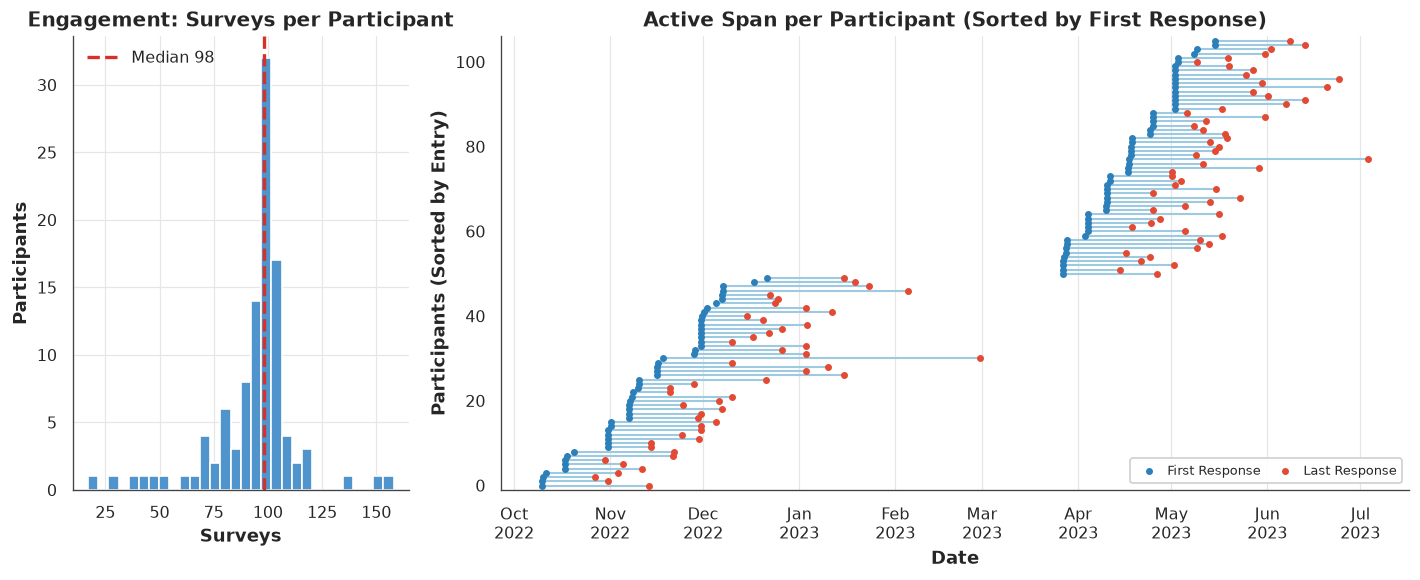

In [3]:
# E2 · Participant engagement and active span
import matplotlib.dates as mdates

pp_e = df.groupby('id_participant')
n_surv_e = pp_e.size()
span_e = pd.DataFrame({
    'first': pp_e['ts_local'].min(),
    'last': pp_e['ts_local'].max(),
    'n': n_surv_e,
}).sort_values('first')

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0), gridspec_kw={'width_ratios': [1, 2.7]})

# Engagement · surveys per participant
ax = axes[0]
ax.hist(n_surv_e.values, bins=30, color='#4F94CD', edgecolor='white')
ax.axvline(n_surv_e.median(), color='#d73027', ls='--', lw=2,
           label=f'Median {n_surv_e.median():.0f}')
ax.set_title('Engagement: Surveys per Participant')
ax.set_xlabel('Surveys'); ax.set_ylabel('Participants')
ax.legend()

# Active span · first-to-last response per participant
ax = axes[1]
yv = np.arange(len(span_e))
ax.hlines(yv, span_e['first'].values, span_e['last'].values, color='#9ecae1', lw=1.25)
ax.scatter(span_e['first'].values, yv, s=10, color='#2c7fb8', label='First Response', zorder=3)
ax.scatter(span_e['last'].values, yv, s=10, color='#e34a33', label='Last Response', zorder=3)
ax.set_title('Active Span per Participant (Sorted by First Response)')
ax.set_xlabel('Date'); ax.set_ylabel('Participants (Sorted by Entry)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.grid(axis='y', visible=False)
ax.margins(y=0.01)
ax.legend(loc='lower right', ncol=2, fontsize=8, frameon=True, framealpha=0.92,
          edgecolor='#cccccc', handletextpad=0.4, columnspacing=0.8)

fig.tight_layout()
fig.savefig(FIG_DIR / 'participant_engagement.pdf', bbox_inches='tight')
plt.show()

### Figure 5 · Weekly temporal cadence
*Paper §3.1 · ref D2*

The cadence reflects a protocol built around the **working day**: responses concentrate between **9 AM and 7 PM** and peak in the mid-afternoon, and **weekdays account for all but ~17%** of the data. The calendar-week panel rises and falls with the phased recruitment of participants.

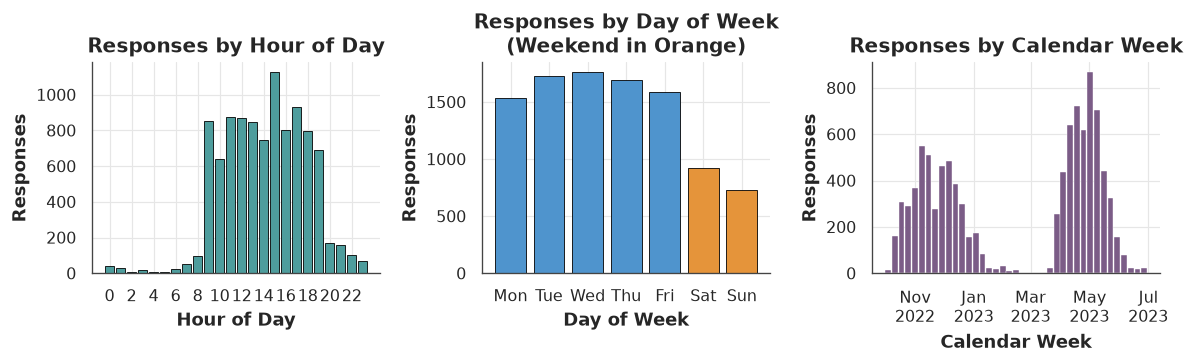

In [4]:
# D2 · Compact weekly temporal cadence
import matplotlib.dates as mdates

t = df['ts_local']
hour = t.dt.hour
dow = t.dt.dayofweek
DOW_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))

# 1 · by hour of day
ax = axes[0]
hc = hour.value_counts().reindex(range(24), fill_value=0)
ax.bar(hc.index, hc.values, color='#4E9D9D', edgecolor='black', linewidth=0.5)
ax.set_title('Responses by Hour of Day'); ax.set_xlabel('Hour of Day'); ax.set_ylabel('Responses')
ax.set_xticks(range(0, 24, 2))

# 2 · by day of week
ax = axes[1]
dc = dow.value_counts().reindex(range(7), fill_value=0)
colors = ['#4F94CD'] * 5 + ['#E5943A'] * 2
ax.bar([DOW_LABELS[i] for i in dc.index], dc.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Responses by Day of Week\n(Weekend in Orange)')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Responses')

# 3 · by calendar week
week_start = t.dt.tz_localize(None).dt.to_period('W-MON').apply(lambda p: p.start_time)
wc = week_start.value_counts().sort_index()
ax = axes[2]
ax.bar(wc.index, wc.values, width=6, color='#7B5C87', edgecolor='white', linewidth=0.25)
ax.set_title('Responses by Calendar Week'); ax.set_xlabel('Calendar Week'); ax.set_ylabel('Responses')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelrotation=0)

plt.tight_layout()
fig.savefig(FIG_DIR / 'weekly_temporal_cadence.pdf', bbox_inches='tight')
plt.show()


### Figure 6 · Space-type response timing (row-normalized)
*Paper §3.1 · ref D4*

Normalizing within each space type turns timing into a **temporal signature** for when each kind of space is used. Offices and classrooms are almost exclusively weekday, daytime settings (~96% of office responses on weekdays); **home** stretches into the evening and holds the largest weekend share; and the **commute** spaces (outdoor, transportation) break from the indoor mid-afternoon peak to rise around **18:00–19:00**. Timing alone already begins to separate the spaces before any perception is considered.

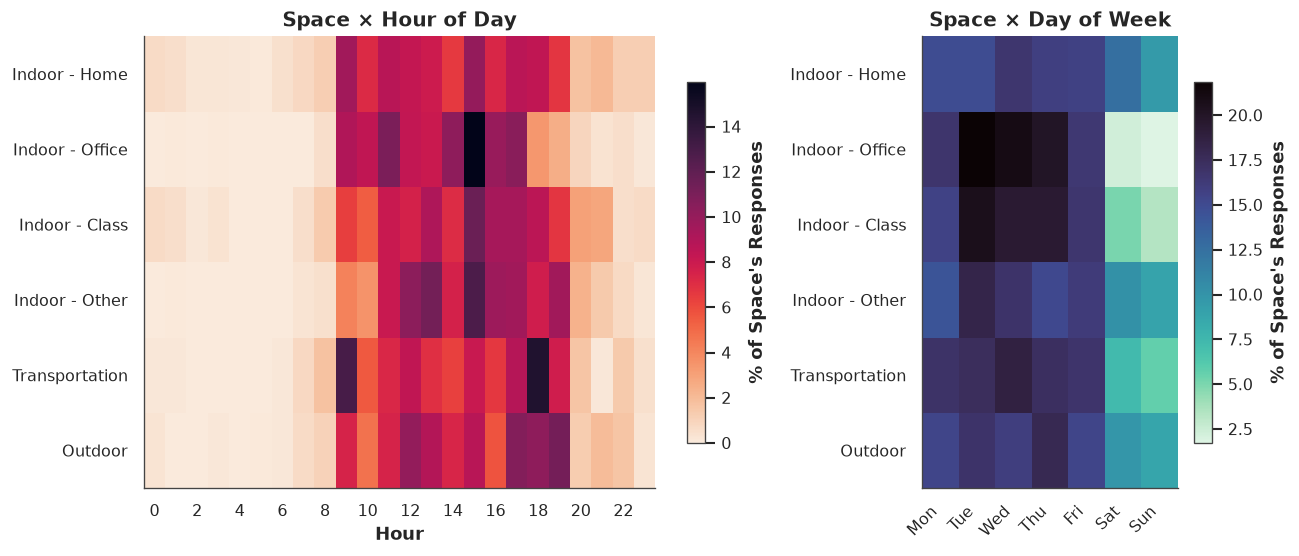

In [5]:
locs = [l for l in LOC_ORDER if l in df['q_location'].unique()]
# D4 · location × time heatmaps (row-normalised)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), gridspec_kw={'width_ratios': [2, 1]})

# (a) space × hour
ax = axes[0]
hh = df.assign(hour=df['ts_local'].dt.hour)
mat = pd.crosstab(hh['q_location'], hh['hour'], normalize='index').reindex(locs).reindex(columns=range(24), fill_value=0)
im = ax.imshow(mat.values*100, cmap='rocket_r', aspect='auto')
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels(range(0, 24, 2))
ax.set_yticks(range(len(locs))); ax.set_yticklabels(locs)
ax.set_title('Space × Hour of Day'); ax.set_xlabel('Hour'); ax.grid(False)
fig.colorbar(im, ax=ax, label='% of Space\'s Responses', shrink=0.8)

# (b) space × day of week
ax = axes[1]
dd = df.assign(dow=df['ts_local'].dt.dayofweek)
mat2 = pd.crosstab(dd['q_location'], dd['dow'], normalize='index').reindex(locs).reindex(columns=range(7), fill_value=0)
im = ax.imshow(mat2.values*100, cmap='mako_r', aspect='auto')
ax.set_xticks(range(7)); ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45, ha='right')
ax.set_yticks(range(len(locs))); ax.set_yticklabels(locs)
ax.set_title('Space × Day of Week'); ax.grid(False)
fig.colorbar(im, ax=ax, label='% of Space\'s Responses', shrink=0.8)

plt.tight_layout()
fig.savefig(FIG_DIR / 'space_type_timing_heatmaps.pdf', bbox_inches='tight')
plt.show()

---
## 4 · Survey responses and linked temporal coverage
*Paper §3.2 · Figures 7–10*

### Figure 7 · Survey battery and linked-sensor coverage
*Paper §3.2 · ref A1*

Read together, the panels sketch the typical reported moment. **Thermal preference** is strongly asymmetric — *No change* 54%, *Cooler* 40%, *Warmer* just 6% — the expected pattern for a warm, humid climate (and heavily air-conditioned indoor spaces). **Perceived noise** is more balanced (*None* 46%, *A little* 44%, *A lot* ~10%), and where noise is present it is attributed most often to **people talking** (44% of noise-kind responses), ahead of appliances and traffic. Most responses come from **home (45%)**, participants are usually **Alone (72%)**, and earphone use is uncommon. The coverage panel shows the linked analysis is feasible: the **one-hour** pre-survey window carries weather for ~96% of surveys and heart rate, movement, and measured noise for ~90%.

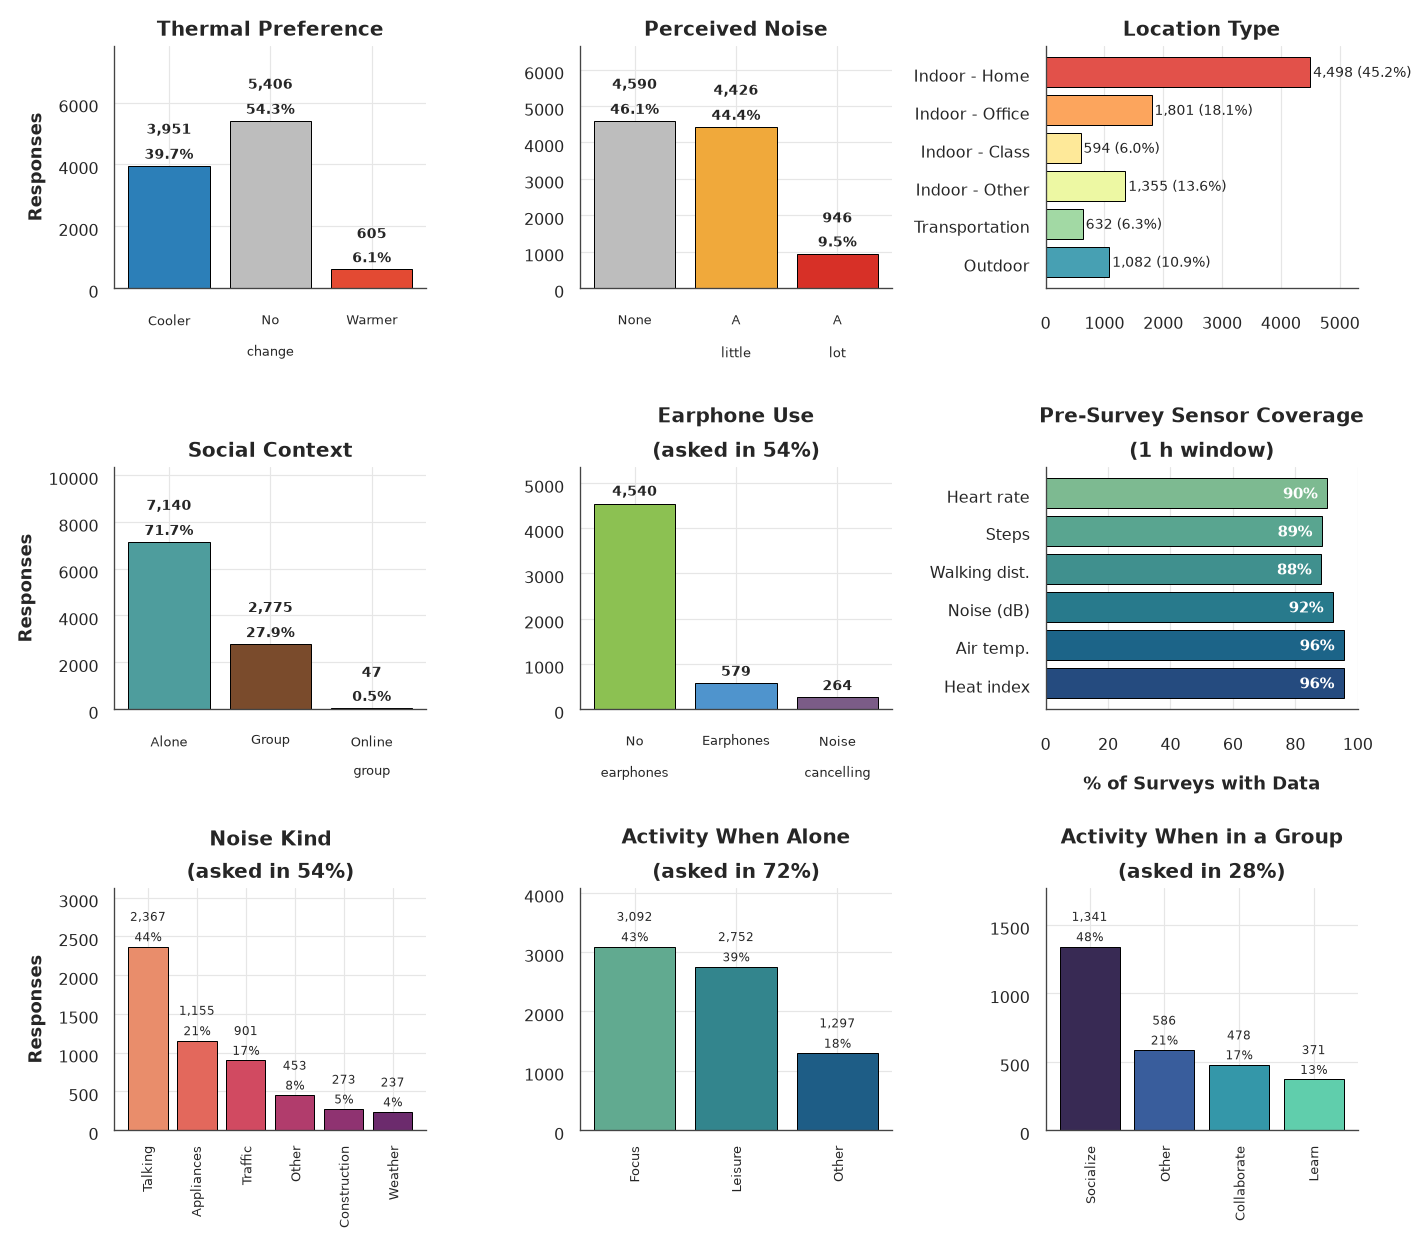

In [6]:
N = len(df)

def ordered_counts(col, order):
    vc = df[col].value_counts()
    return [(k, int(vc.get(k, 0))) for k in order]

def annotate_v(ax, bars, denom=N):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h, f'{int(h):,}\n{h/denom*100:.1f}%',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

def wrap_words(s):
    # put each word on its own line so multiword tick labels stay narrow
    return s.replace(' ', '\n')

def set_cat_xticklabels(ax, labels, **kw):
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, **kw)

fig, axes = plt.subplots(3, 3, figsize=(12, 10.5))

# 1 · thermal preference
ax = axes[0, 0]
kv = ordered_counts('q_thermal_preference', THERMAL_ORDER)
bars = ax.bar([k for k, _ in kv], [v for _, v in kv],
              color=[THERMAL_COLOR[k] for k, _ in kv], edgecolor='black', linewidth=0.6)
annotate_v(ax, bars); ax.set_title('Thermal Preference'); ax.set_ylabel('Responses')
set_cat_xticklabels(ax, [wrap_words(k) for k, _ in kv], fontsize=8); ax.margins(y=0.45)

# 2 · perceived noise
ax = axes[0, 1]
kv = ordered_counts('q_noise_nearby', NOISE_ORDER)
bars = ax.bar([k for k, _ in kv], [v for _, v in kv],
              color=[NOISE_COLOR[k] for k, _ in kv], edgecolor='black', linewidth=0.6)
annotate_v(ax, bars); ax.set_title('Perceived Noise')
set_cat_xticklabels(ax, [wrap_words(k) for k, _ in kv], fontsize=8); ax.margins(y=0.45)

# 3 · location (horizontal, ordered by frequency)
ax = axes[0, 2]
loc = df['q_location'].value_counts().reindex(LOC_ORDER).dropna()
bars = ax.barh([str(i) for i in loc.index], loc.values,
               color=[LOC_PALETTE[i] for i in loc.index], edgecolor='black', linewidth=0.6)
for i, v in enumerate(loc.values):
    ax.text(v + N*0.005, i, f'{int(v):,} ({v/N*100:.1f}%)', va='center', fontsize=8.5)
ax.set_title('Location Type'); ax.invert_yaxis(); ax.margins(x=0.18); ax.grid(axis='y', visible=False)

# 4 · social context
ax = axes[1, 0]
soc = df['q_alone_group'].value_counts().reindex(['Alone', 'Group', 'Online group']).dropna()
bars = ax.bar([str(i) for i in soc.index], soc.values,
              color=['#4E9D9D', '#7A4B2C', '#c7c7c7'], edgecolor='black', linewidth=0.6)
annotate_v(ax, bars); ax.set_title('Social Context'); ax.set_ylabel('Responses')
set_cat_xticklabels(ax, [wrap_words(str(i)) for i in soc.index], fontsize=8); ax.margins(y=0.45)

# 5 · earphones (partial-coverage question)
ax = axes[1, 1]
ep = df['q_earphones'].value_counts().reindex(['No earphones', 'Earphones', 'Noise cancelling']).dropna()
bars = ax.bar([str(i) for i in ep.index], ep.values,
              color=['#8CC152', '#4F94CD', '#7B5C87'], edgecolor='black', linewidth=0.6)
cov_ep = df['q_earphones'].notna().mean()
for b in bars:
    h = b.get_height()
    ax.text(b.get_x()+b.get_width()/2, h, f'{int(h):,}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold')
ax.set_title(f'Earphone Use\n(asked in {cov_ep*100:.0f}%)')
set_cat_xticklabels(ax, [wrap_words(str(i)) for i in ep.index], fontsize=8); ax.margins(y=0.18)

# 6 · pre-survey sensor coverage (1-hour window)
ax = axes[1, 2]
cov_specs = [('Heart rate', 'hr_count_1h'), ('Steps', 'steps_count_1h'),
             ('Walking dist.', 'walk_count_1h'), ('Noise (dB)', 'audio_count_1h'),
             ('Air temp.', 'temp_count_1h'), ('Heat index', 'heat_index_mean_1h')]
labels = [l for l, _ in cov_specs]
covs = [ (df[c] > 0).mean()*100 if c.endswith('count_1h') else df[c].notna().mean()*100
         for _, c in cov_specs ]
bars = ax.barh(labels, covs, color=sns.color_palette('crest', len(labels)), edgecolor='black', linewidth=0.6)
for i, v in enumerate(covs):
    ax.text(v - 3, i, f'{v:.0f}%', va='center', ha='right', color='white', fontsize=9, fontweight='bold')
ax.set_title('Pre-Survey Sensor Coverage\n(1 h window)'); ax.set_xlim(0, 100)
ax.invert_yaxis(); ax.set_xlabel('% of Surveys with Data'); ax.grid(axis='y', visible=False)

# ---- row 3 · conditional follow-up questions (partial coverage; % shown over answered responses) ----
def conditional_bar(ax, col, title, palette):
    vc = df[col].value_counts()                     # descending by frequency
    ans = int(vc.sum())                             # answered (non-null) responses
    cov = df[col].notna().mean() * 100
    bars = ax.bar([str(i) for i in vc.index], vc.values,
                  color=sns.color_palette(palette, len(vc)), edgecolor='black', linewidth=0.6)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h, f'{int(h):,}\n{h/ans*100:.0f}%',
                ha='center', va='bottom', fontsize=7)
    ax.set_title(f'{title}\n(asked in {cov:.0f}%)')
    set_cat_xticklabels(ax, [str(i) for i in vc.index], rotation=90, ha='center',
                        va='top', fontsize=8)
    ax.margins(y=0.32)

# 7 · what kind of noise
conditional_bar(axes[2, 0], 'q_noise_kind', 'Noise Kind', 'flare')
axes[2, 0].set_ylabel('Responses')

# 8 · activity category when alone
conditional_bar(axes[2, 1], 'q_activity_category_alone', 'Activity When Alone', 'crest')

# 9 · activity category when in a group
conditional_bar(axes[2, 2], 'q_activity_category_group', 'Activity When in a Group', 'mako')

# generous line spacing on every text element so stacked lines never touch
for t in fig.findobj(mpl.text.Text):
    t.set_linespacing(1.7)
# wrapped multi-line tick labels need extra spacing at their smaller font size
for ax in axes.ravel():
    for lbl in ax.get_xticklabels():
        lbl.set_linespacing(2.4)

plt.tight_layout()
fig.savefig(FIG_DIR / 'survey_battery_and_coverage.pdf', bbox_inches='tight')
plt.show()

### Figure 8 · Survey response flow (Sankey)
*Paper §3.2 · ref C1*

The same responses shown as a **flow through the questions** makes the conditional structure explicit: each answer splits into the next question, conditional branches (noise kind, earphones) carry only the ~half of responses that reach them, and activity divides by *Alone* vs. *Group*. Ribbon widths are drawn to scale; the common home / solitary / *No change*–*Cooler* responses form the thick central spine.

> **Provenance note.** The manuscript's Figure 8 (`cozie-sankey-organized.png`) is a manually reorganized layout of this Sankey for readability. The cell below regenerates the **analytical source** (`survey_response_flow.pdf`), which is topologically identical; the hand-organized PNG the manuscript includes is left untouched.

In [7]:
# C1 · full survey-response flow (Sankey). Node order within each column follows the
# publication reference arrangement (top → bottom) so the default render is deterministic.
stages = {
    'noise_nearby': ['A lot', 'A little', 'None'],
    'noise_kind'  : ['Construction', 'Appliances', 'Other', 'Talking', 'Weather', 'Traffic'],
    'earphones'   : ['Noise cancelling', 'No earphones', 'Earphones'],
    'thermal'     : ['Warmer', 'No change', 'Cooler'],
    'location'    : ['Indoor - Office', 'Indoor - Other', 'Indoor - Home',
                     'Indoor - Class', 'Outdoor', 'Transportation'],
    'office'      : ['Conference room', 'Small shared', 'Individual', 'Large open plan', 'Cubicles'],
    'transport'   : ['Car', 'Taxi', 'Bus', 'Train', 'Other'],
    'social'      : ['Alone', 'Group', 'Online group'],
    'act_alone'   : ['Focus', 'Leisure', 'Other'],
    'act_group'   : ['Socialize', 'Learn', 'Collaborate', 'Other'],
}
count_col = {
    'noise_nearby': 'q_noise_nearby', 'noise_kind': 'q_noise_kind', 'earphones': 'q_earphones',
    'thermal': 'q_thermal_preference', 'location': 'q_location', 'office': 'q_location_office',
    'transport': 'q_location_transport', 'social': 'q_alone_group',
    'act_alone': 'q_activity_category_alone', 'act_group': 'q_activity_category_group',
}
# Each column is one x-position holding one or more stacked stages (top → bottom).
columns = [
    (0.02,  ['noise_nearby']),
    (0.155, ['noise_kind']),
    (0.29,  ['earphones']),
    (0.42,  ['thermal']),
    (0.55,  ['location']),
    (0.68,  ['office', 'transport']),
    (0.80,  ['social']),
    (0.965, ['act_alone', 'act_group']),
]
stage_color = {'noise_nearby': '#4F94CD', 'noise_kind': '#7B5C87', 'earphones': '#8CC152',
               'thermal': '#E5943A', 'location': '#4E9D9D', 'office': '#1A1A1A',
               'transport': '#7FC6E4', 'social': '#7A4B2C', 'act_alone': '#CDA24C', 'act_group': '#CDA24C'}
TOTAL = len(df)

def node_count(stage, val):
    return int((df[count_col[stage]] == val).sum())

labels, colors, xs, ys, idx = [], [], [], [], {}
for x, member_stages in columns:
    combined = [(s, v) for s in member_stages for v in stages[s]]  # stacked top → bottom
    n_comb = len(combined)
    for pos, (s, v) in enumerate(combined):
        y = 0.05 + 0.88 * (pos + 0.5) / n_comb
        c = node_count(s, v); pct = 100 * c / TOTAL
        idx[(s, v)] = len(labels)
        labels.append(f"{v}<br>{c:,} ({pct:.1f}%)")
        colors.append(stage_color[s]); xs.append(x); ys.append(y)

S, T, V = [], [], []
def add(gr, s_stage, s_col, t_stage, t_col):
    grp = gr.groupby([s_col, t_col]).size().reset_index(name='n')
    for _, r in grp.iterrows():
        if (s_stage, r[s_col]) in idx and (t_stage, r[t_col]) in idx:
            S.append(idx[(s_stage, r[s_col])]); T.append(idx[(t_stage, r[t_col])]); V.append(int(r['n']))

through = df[df['q_earphones'].notna()]
bypass  = df[df['q_earphones'].isna()]
add(through, 'noise_nearby', 'q_noise_nearby', 'noise_kind', 'q_noise_kind')
add(through, 'noise_kind', 'q_noise_kind', 'earphones', 'q_earphones')
add(through, 'earphones', 'q_earphones', 'thermal', 'q_thermal_preference')
add(bypass,  'noise_nearby', 'q_noise_nearby', 'thermal', 'q_thermal_preference')
add(df, 'thermal', 'q_thermal_preference', 'location', 'q_location')
office_rows = df[df['q_location'] == 'Indoor - Office']
trans_rows  = df[df['q_location'] == 'Transportation']
other_rows  = df[~df['q_location'].isin(['Indoor - Office', 'Transportation'])]
add(office_rows, 'location', 'q_location', 'office', 'q_location_office')
add(trans_rows,  'location', 'q_location', 'transport', 'q_location_transport')
add(office_rows, 'office', 'q_location_office', 'social', 'q_alone_group')
add(trans_rows,  'transport', 'q_location_transport', 'social', 'q_alone_group')
add(other_rows,  'location', 'q_location', 'social', 'q_alone_group')
alone_rows = df[df['q_alone_group'] == 'Alone']
group_rows = df[df['q_alone_group'] == 'Group']
add(alone_rows, 'social', 'q_alone_group', 'act_alone', 'q_activity_category_alone')
add(group_rows, 'social', 'q_alone_group', 'act_group', 'q_activity_category_group')

fig_sankey = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(pad=22, thickness=18, line=dict(color='white', width=0.5),
              label=labels, color=colors, x=xs, y=ys),
    link=dict(source=S, target=T, value=V, color='rgba(150,150,150,0.28)')))
fig_sankey.update_layout(
    title='Survey Response Flow Across the Full Question Battery',
    font=dict(size=11, family='Helvetica, Arial, sans-serif', color='#2c3e50'),
    paper_bgcolor='white', plot_bgcolor='white',
    width=1750, height=760, margin=dict(l=90, r=110, t=55, b=60))
fig_sankey.write_image(FIG_DIR / 'survey_response_flow.pdf', format='pdf', width=1750, height=760)
fig_sankey.show()
print(f"nodes: {len(labels)}  |  links: {len(S)}")

nodes: 41  |  links: 116


### Figure 9 · Wearable-health metrics across pre-survey windows
*Paper §3.2 · ref A2*

The **window matters most for movement**: median step count and walking distance fall as the window narrows (from ~85 to ~42 steps per reading between the six-hour and ten-minute windows), while **heart rate is stable at ~80 bpm** across all three. **Coverage moves the other way**: the six-hour window carries movement and noise for >95% of surveys, but at ten minutes audio coverage falls to ~a third and step coverage to little more than half; resting HR and SpO₂ are sparse throughout. The **one-hour window** is used as the working aggregate because it keeps coverage near 90% while staying close to the survey.

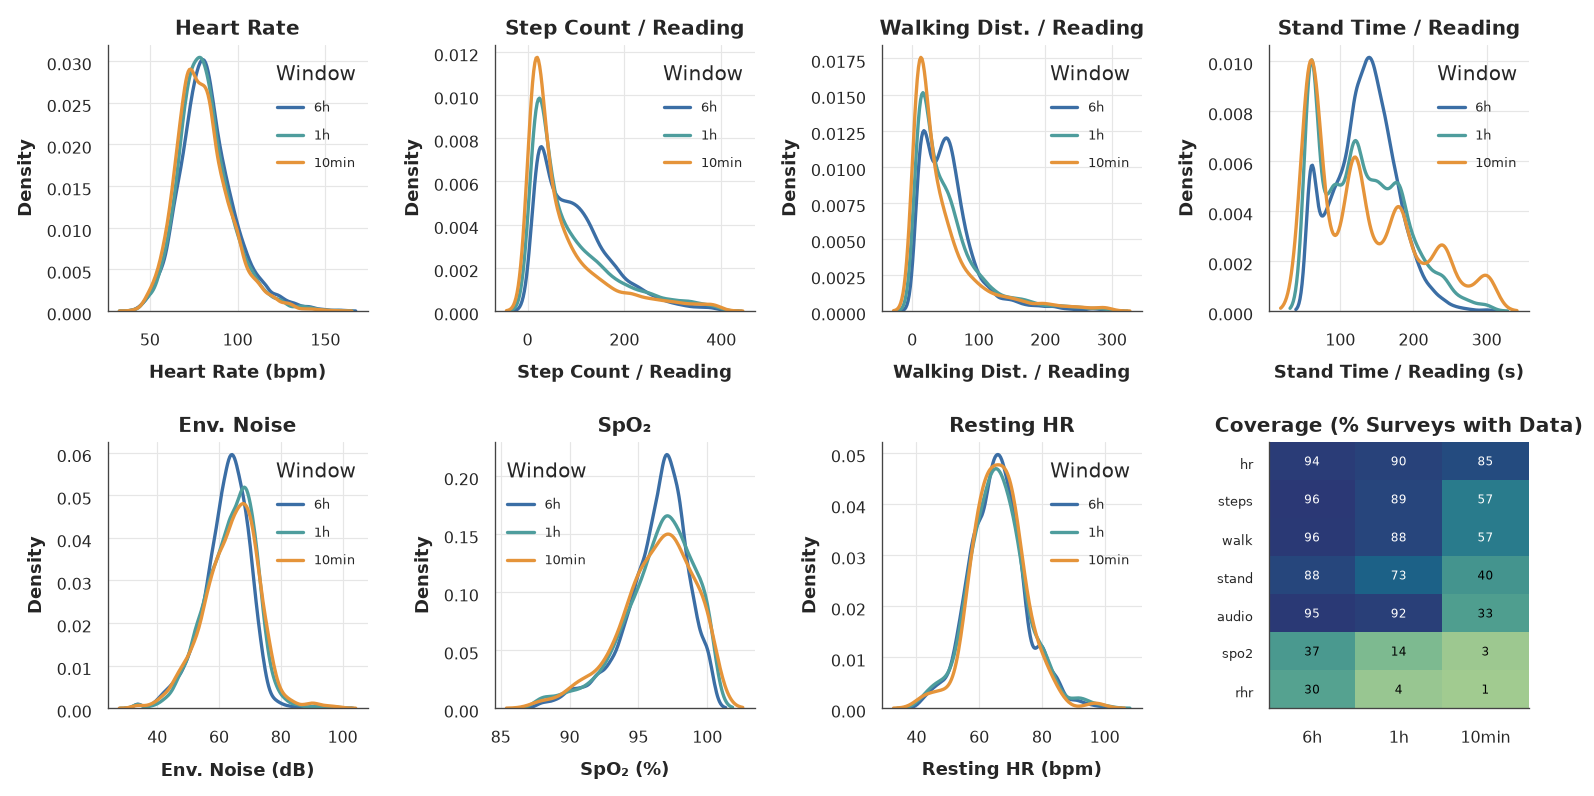

In [8]:
# A2 · health metrics — distribution of the window-mean across 6h/1h/10min + coverage
health_specs = [
    ('hr',    'Heart Rate (bpm)',        (40, 160)),
    ('steps', 'Step Count / Reading',    (0, 400)),
    ('walk',  'Walking Dist. / Reading', (0, 300)),
    ('stand', 'Stand Time / Reading (s)',(60, 300)),
    ('audio', 'Env. Noise (dB)',         (30, 100)),
    ('spo2',  'SpO₂ (%)',                (88, 100)),
    ('rhr',   'Resting HR (bpm)',        (40, 100)),
]
fig, axes = plt.subplots(2, 4, figsize=(13, 6.8))
axf = axes.ravel()
for ax, (prefix, xlabel, clip) in zip(axf, health_specs):
    kde_by_window(ax, prefix, stat='mean', xlabel=xlabel, clip=clip, title=xlabel.split('(')[0].strip())
    h, _ = ax.get_legend_handles_labels()
    if h:
        ax.legend(title='Window', fontsize=8)

# coverage heatmap (metric × window)
ax = axf[7]
cov = np.array([[(pd.to_numeric(df[f'{p}_count_{w}'], errors='coerce') > 0).mean()*100
                 for w in WINDOWS3] for p, _, _ in health_specs])
im = ax.imshow(cov, cmap='crest', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(WINDOWS3)
ax.set_yticks(range(len(health_specs))); ax.set_yticklabels([p for p, _, _ in health_specs], fontsize=8)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        ax.text(j, i, f'{cov[i,j]:.0f}', ha='center', va='center', fontsize=7,
                color='white' if cov[i,j] > 55 else 'black')
ax.set_title('Coverage (% Surveys with Data)'); ax.grid(False)

# generous line spacing on every text element so stacked lines never touch
for t in fig.findobj(mpl.text.Text):
    t.set_linespacing(1.6)

plt.tight_layout()
fig.savefig(FIG_DIR / 'wearable_health_windows.pdf', bbox_inches='tight')
plt.show()

### Figure 10 · Outdoor weather across pre-survey windows
*Paper §3.2 · ref A3*

The nearest-station distributions are **narrow and stable**, as expected for an equatorial climate: air temperature median near **29 °C**, relative humidity near **73%**, and a derived **heat index around 34 °C** that changes little across windows. **Rainfall** is the one strongly window-dependent feature because it accumulates (~28% of six-hour windows contain rain vs. ~5% of ten-minute windows). These are outdoor conditions at a station a median of ~3 km away — **not** the participant's actual microclimate, which is often indoor and air-conditioned.

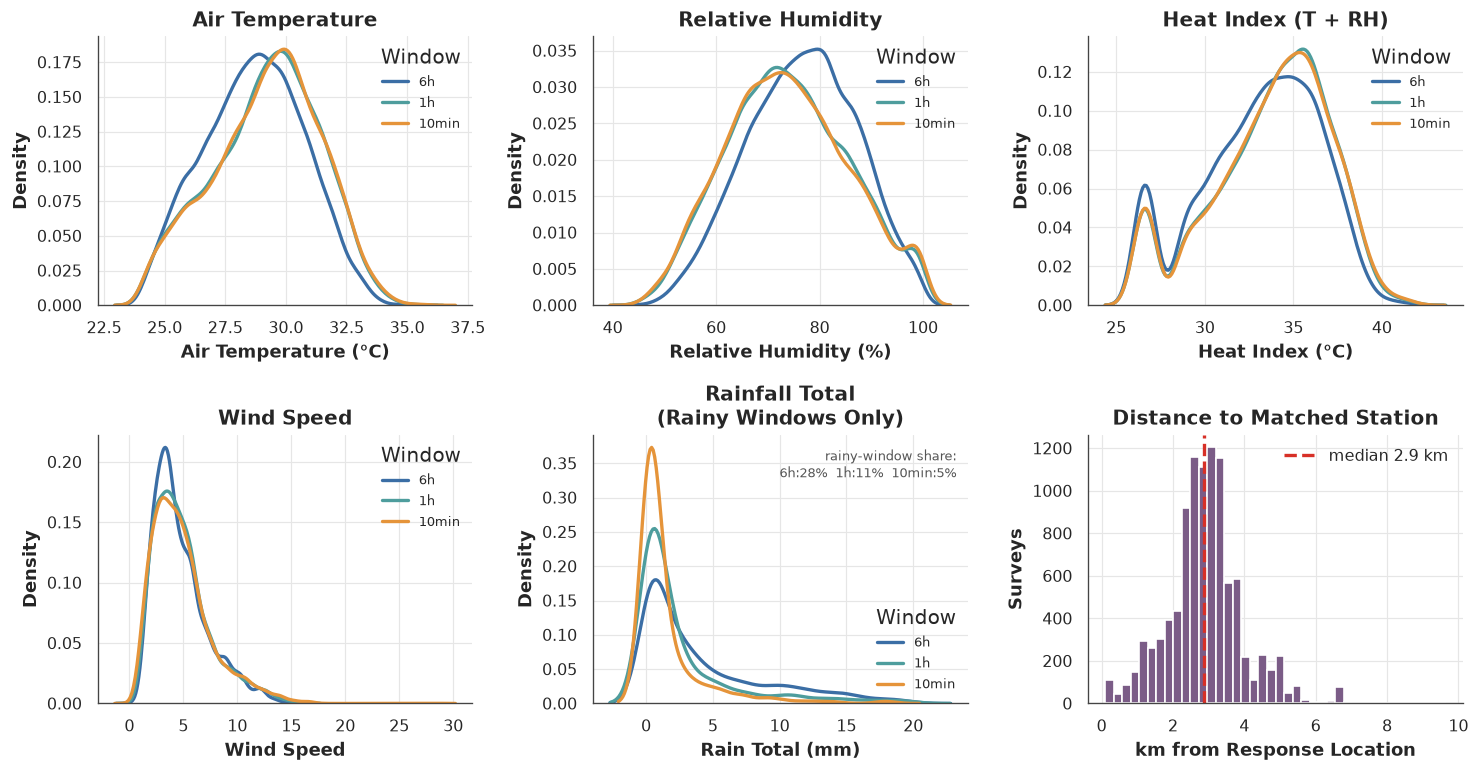

In [9]:
# A3 · weather metrics (outdoor) — window distributions across 6h/1h/10min
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.6))
axf = axes.ravel()

kde_by_window(axf[0], 'temp', 'mean', xlabel='Air Temperature (°C)', clip=(24, 40), title='Air Temperature')
kde_by_window(axf[1], 'rh',   'mean', xlabel='Relative Humidity (%)', clip=(45, 100), title='Relative Humidity')
kde_by_window(axf[2], 'heat_index', 'mean', xlabel='Heat Index (°C)', clip=(26, 42), title='Heat Index (T + RH)')
kde_by_window(axf[3], 'wind_speed', 'mean', xlabel='Wind Speed', clip=(0, 40), title='Wind Speed')
for ax in axf[:4]:
    h, _ = ax.get_legend_handles_labels()
    if h:
        ax.legend(title='Window', fontsize=8)

# Rainfall total accumulates over the window, so 6h ≥ 1h ≥ 10min by construction.
ax = axf[4]
for w in WINDOWS3:
    s = pd.to_numeric(df[f'rain_total_{w}'], errors='coerce').dropna()
    s = s[(s > 0) & (s <= 20)]   # rainy windows only, for shape
    if len(s) > 5:
        sns.kdeplot(s, ax=ax, color=WIN_COLOR[w], lw=2, label=w, warn_singular=False)
ax.set_title('Rainfall Total\n(Rainy Windows Only)'); ax.set_xlabel('Rain Total (mm)'); ax.set_ylabel('Density')
ax.legend(title='Window', fontsize=8)
rainy = {w: (pd.to_numeric(df[f'rain_total_{w}'], errors='coerce') > 0).mean()*100 for w in WINDOWS3}
ax.text(0.97, 0.95, 'rainy-window share:\n' + '  '.join(f'{w}:{rainy[w]:.0f}%' for w in WINDOWS3),
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#555')

# Station distance
ax = axf[5]
dist = pd.to_numeric(df['weather_station_dist_km'], errors='coerce').dropna()
ax.hist(dist, bins=40, color='#7B5C87', edgecolor='white')
ax.axvline(dist.median(), color='#d73027', ls='--', lw=2, label=f'median {dist.median():.1f} km')
ax.set_title('Distance to Matched Station'); ax.set_xlabel('km from Response Location'); ax.set_ylabel('Surveys')
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / 'outdoor_weather_windows.pdf', bbox_inches='tight')
plt.show()


---
## 5 · Thermal preference and noise characterization
*Paper §3.3 · Figures 11–12*

The two dominant strands of the reported experience — wanting to be **cooler** and being
**distracted by noise** — are examined here before they are related to space type.

### Figure 11 · Cooling preference patterns
*Paper §3.3 · ref F2*

Cooling demand is real but only **loosely tied to the outdoor thermometer**. Across all responses, the *Cooler* share rises with outdoor heat — from about a third when the pre-survey heat index is near 30 °C to roughly half above 37 °C — the expected direction for a tropical setting. But the link is **much weaker between people**: a participant's mean outdoor temperature explains little of who wants cooling (**r ≈ 0.33**), and the *Cooler* share ranges from under 10% for the most heat-tolerant participants to nearly 80% for the most cooling-seeking. **Cooling preference is as much a personal trait as a response to measured conditions** — exactly the individual variation person-level sensing is designed to capture.

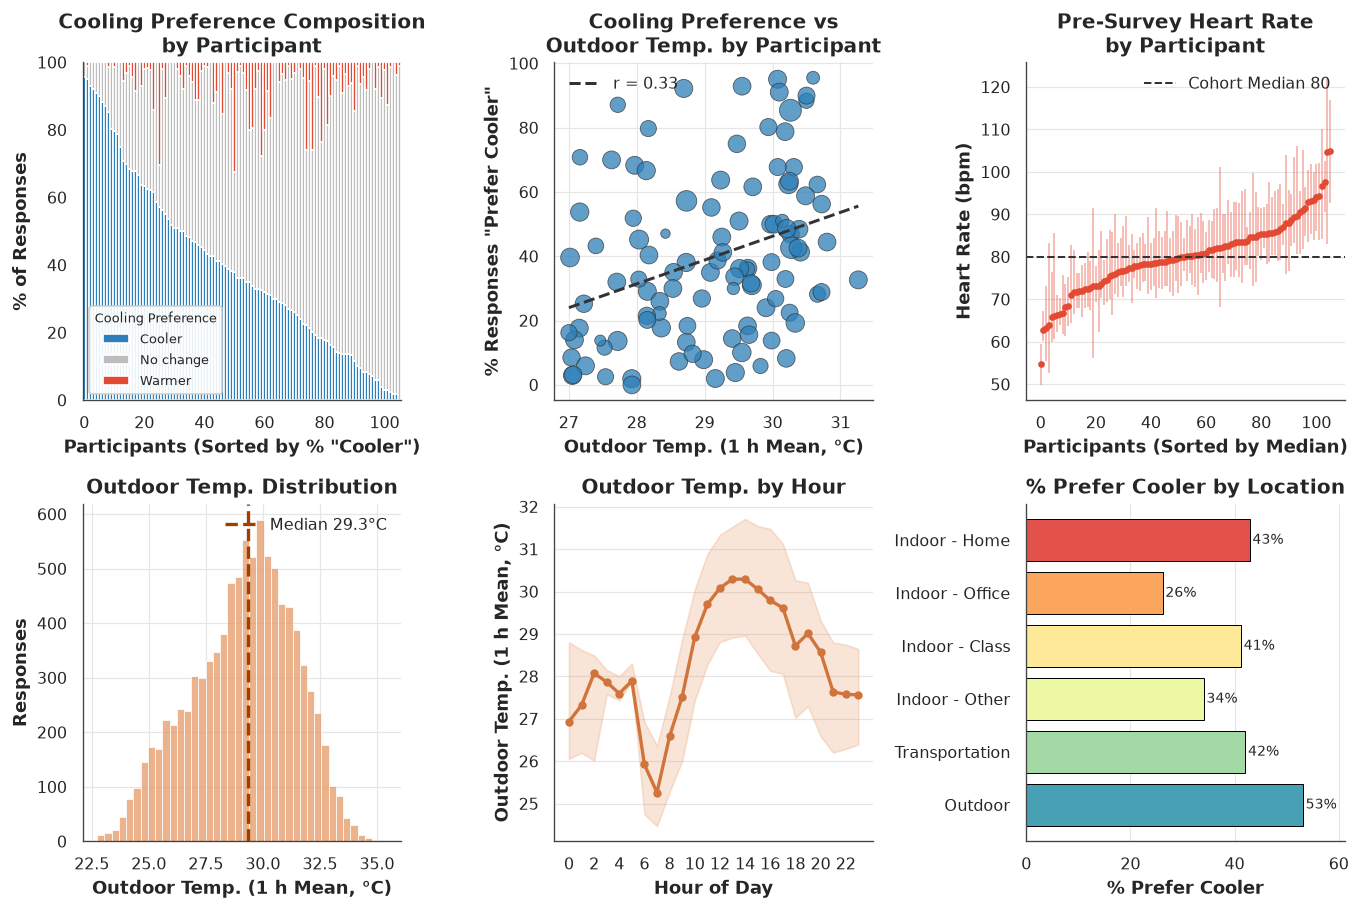

In [10]:
# F2 · Participant heat and cooling preference patterns
# Six panels: participant composition, person-level temperature relationship, physiology, outdoor
# temperature distribution and diurnal profile, and location-specific cooling preference.
TEMP_LABEL = 'Outdoor Temp. (1 h Mean, °C)'

pp_heat = df.groupby('id_participant')
n_surv_heat = pp_heat.size()
pref_share_heat = (df.groupby(['id_participant', 'q_thermal_preference']).size()
                     .unstack(fill_value=0))
pref_share_heat = pref_share_heat.div(pref_share_heat.sum(axis=1), axis=0)[THERMAL_ORDER]
order_cooler = pref_share_heat.sort_values('Cooler', ascending=False).index
pp_heat_env = pd.DataFrame({
    'n': n_surv_heat,
    'pct_cooler': pref_share_heat['Cooler'] * 100,
    'temperature': pp_heat['temp_mean_1h'].mean(),
}).dropna(subset=['temperature'])

# Per-participant 1 h heart-rate median and IQR, sorted by median.
hr_group = df[['id_participant', 'hr_mean_1h']].assign(
    hr_mean_1h=lambda x: pd.to_numeric(x['hr_mean_1h'], errors='coerce')
).dropna().groupby('id_participant')['hr_mean_1h']
hr_stat_heat = pd.DataFrame({
    'med': hr_group.median(), 'q1': hr_group.quantile(.25), 'q3': hr_group.quantile(.75)
}).sort_values('med')

temp = pd.to_numeric(df['temp_mean_1h'], errors='coerce')
locs_heat = [loc for loc in LOC_ORDER if loc in df['q_location'].unique()]

fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.75))

# 1 · Cooling-preference composition per participant
ax = axes[0, 0]
bottom = np.zeros(len(order_cooler))
xpos = np.arange(len(order_cooler))
for pref in THERMAL_ORDER:
    vals = pref_share_heat.loc[order_cooler, pref].values * 100
    ax.bar(xpos, vals, bottom=bottom, color=THERMAL_COLOR[pref], width=1.0, label=pref)
    bottom += vals
ax.set_title('Cooling Preference Composition\nby Participant')
ax.set_xlabel('Participants (Sorted by % "Cooler")'); ax.set_ylabel('% of Responses')
ax.set_xlim(-0.5, len(order_cooler)-0.5); ax.set_ylim(0, 100); ax.grid(axis='x', visible=False)
ax.legend(title='Cooling Preference', ncol=1, loc='lower left', fontsize=8, title_fontsize=8,
          frameon=True, framealpha=0.9, edgecolor='#cccccc')

# 2 · Cooling preference vs mean outdoor temperature (per participant), single colour
ax = axes[0, 1]
ax.scatter(pp_heat_env['temperature'], pp_heat_env['pct_cooler'], s=15 + pp_heat_env['n'],
           color='#2c7fb8', edgecolor='#333', linewidth=0.5, alpha=0.75)
r_temp = np.corrcoef(pp_heat_env['temperature'], pp_heat_env['pct_cooler'])[0, 1]
b1, b0 = np.polyfit(pp_heat_env['temperature'], pp_heat_env['pct_cooler'], 1)
xs = np.linspace(pp_heat_env['temperature'].min(), pp_heat_env['temperature'].max(), 50)
ax.plot(xs, b0 + b1*xs, color='#333', lw=1.8, ls='--', label=f'r = {r_temp:.2f}')
ax.set_title('Cooling Preference vs\nOutdoor Temp. by Participant')
ax.set_xlabel(TEMP_LABEL); ax.set_ylabel('% Responses "Prefer Cooler"')
ax.legend(loc='upper left')

# 3 · Pre-survey heart rate by participant
ax = axes[0, 2]
x = np.arange(len(hr_stat_heat))
ax.vlines(x, hr_stat_heat['q1'], hr_stat_heat['q3'], color='#e34a33', alpha=0.35, lw=1.2)
ax.plot(x, hr_stat_heat['med'], 'o', ms=3, color='#e34a33')
ax.axhline(hr_stat_heat['med'].median(), color='#333', ls='--', lw=1.2,
           label=f'Cohort Median {hr_stat_heat["med"].median():.0f}')
ax.set_title('Pre-Survey Heart Rate\nby Participant')
ax.set_xlabel('Participants (Sorted by Median)'); ax.set_ylabel('Heart Rate (bpm)')
ax.legend(); ax.grid(axis='x', visible=False)

# 4 · Outdoor air temperature distribution
ax = axes[1, 0]
sns.histplot(temp.dropna(), bins=40, ax=ax, color='#e59866', edgecolor='white')
ax.axvline(temp.median(), color='#a04000', ls='--', lw=2, label=f'Median {temp.median():.1f}°C')
ax.set_title('Outdoor Temp. Distribution'); ax.set_xlabel(TEMP_LABEL); ax.set_ylabel('Responses')
ax.legend()

# 5 · Diurnal outdoor temperature (all 24 hours plotted uniformly, no sample-size screening)
ax = axes[1, 1]
tt = pd.DataFrame({'h': df['ts_local'].dt.hour, 'v': temp}).dropna()
gh = tt.groupby('h')['v']
med = gh.median().reindex(range(24)); q1 = gh.quantile(.25).reindex(range(24)); q3 = gh.quantile(.75).reindex(range(24))
ax.fill_between(range(24), q1.values, q3.values, color='#e59866', alpha=0.25)
ax.plot(range(24), med.values, marker='o', ms=4, color='#d0743c', lw=2)
ax.set_title('Outdoor Temp. by Hour'); ax.set_xlabel('Hour of Day'); ax.set_ylabel(TEMP_LABEL)
ax.set_xticks(range(0, 24, 2)); ax.grid(axis='x', visible=False)

# 6 · Cooling preference by location
ax = axes[1, 2]
pct_cooler_loc = (df.groupby('q_location')['q_thermal_preference']
                    .apply(lambda s: (s == 'Cooler').mean() * 100).reindex(locs_heat))
bars = ax.barh([str(loc) for loc in pct_cooler_loc.index], pct_cooler_loc.values,
               color=[LOC_PALETTE[loc] for loc in pct_cooler_loc.index], edgecolor='black', linewidth=0.6)
for i, value in enumerate(pct_cooler_loc.values):
    ax.text(value + 0.5, i, f'{value:.0f}%', va='center', fontsize=8.5)
ax.set_title('% Prefer Cooler by Location'); ax.set_xlabel('% Prefer Cooler')
ax.invert_yaxis(); ax.grid(axis='y', visible=False); ax.margins(x=0.15)

plt.tight_layout()
fig.savefig(FIG_DIR / 'cooling_preference.pdf', bbox_inches='tight')
plt.show()


### Figure 12 · Measured sound level and context
*Paper §3.3 · ref G1*

Here the self-reports and the sensor **agree well**. Measured sound level rises steadily with perceived noise — median near **62 dB** for *None*, **66 dB** for *A little*, and **70 dB** for *A lot* — a consistent separation despite the coarse three-point scale. Levels also track **where people are**: home and office are the quietest settings (~62 dB), while other-indoor, transportation, and outdoor sit near 69–70 dB, and the sources most often reported as loud — traffic and talking — carry the highest levels. Together, Figures 11–12 frame the analysis that follows: thermal preference is a **personal** signal that loosely tracks the environment, while noise perception is tied to a **measurable exposure** that varies with the space.

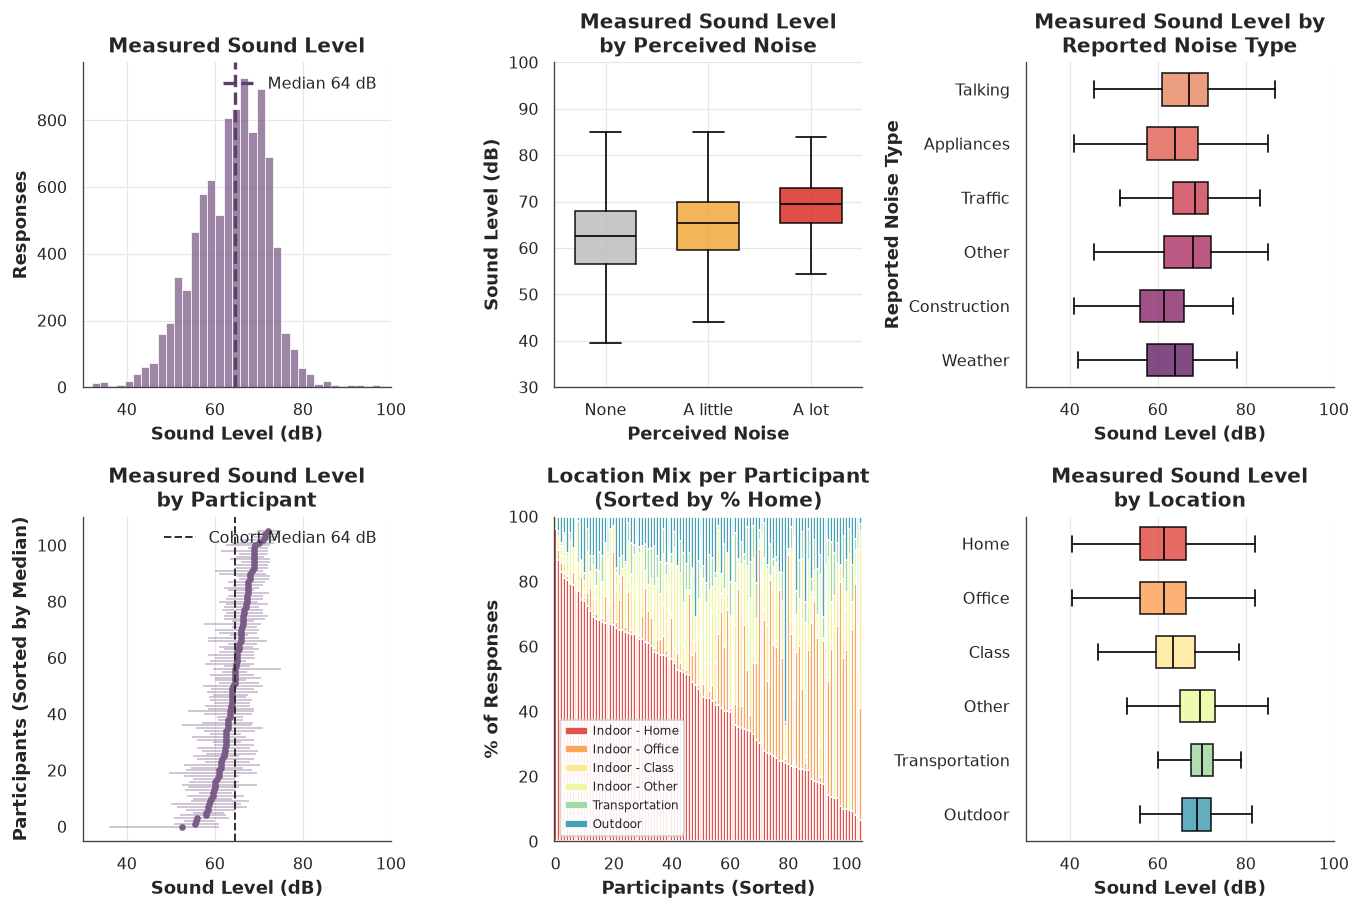

In [11]:
# G1 · Measured sound level and participant/context patterns
SOUND_AXIS = 'Sound Level (dB)'
SOUND_XLIM = (30, 100)
audio = pd.to_numeric(df['audio_mean_1h'], errors='coerce')
locs_noise = [loc for loc in LOC_ORDER if loc in df['q_location'].unique()]

# Per-participant sound-level median and IQR, sorted by median.
audio_group = df[['id_participant', 'audio_mean_1h']].assign(
    audio_mean_1h=lambda x: pd.to_numeric(x['audio_mean_1h'], errors='coerce')
).dropna().groupby('id_participant')['audio_mean_1h']
audio_stat = pd.DataFrame({
    'med': audio_group.median(), 'q1': audio_group.quantile(.25), 'q3': audio_group.quantile(.75)
}).sort_values('med')

# Per-participant location composition, sorted by Home share.
loc_comp_noise = df.groupby(['id_participant', 'q_location']).size().unstack(fill_value=0)
loc_comp_noise = loc_comp_noise.div(loc_comp_noise.sum(axis=1), axis=0)
present_locs_noise = [loc for loc in LOC_ORDER if loc in loc_comp_noise.columns]
loc_comp_noise = loc_comp_noise[present_locs_noise]
order_home_noise = (loc_comp_noise.sort_values('Indoor - Home', ascending=False).index
                    if 'Indoor - Home' in loc_comp_noise else loc_comp_noise.index)

fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.75))

# 1 · Measured sound-level distribution
ax = axes[0, 0]
sns.histplot(audio.dropna(), bins=40, ax=ax, color='#7B5C87', edgecolor='white')
ax.axvline(audio.median(), color='#5e3f69', ls='--', lw=2, label=f'Median {audio.median():.0f} dB')
ax.set_title('Measured Sound Level'); ax.set_xlabel(SOUND_AXIS); ax.set_ylabel('Responses')
ax.set_xlim(SOUND_XLIM); ax.legend()

# 2 · Measured sound level by perceived noise
ax = axes[0, 1]
data_perceived = [audio[df['q_noise_nearby'] == level].dropna().values for level in NOISE_ORDER]
bp = ax.boxplot(data_perceived, tick_labels=NOISE_ORDER, patch_artist=True, showfliers=False, widths=0.6)
for patch, level in zip(bp['boxes'], NOISE_ORDER):
    patch.set_facecolor(NOISE_COLOR[level]); patch.set_alpha(0.85)
for med in bp['medians']:
    med.set_color('black')
ax.set_title('Measured Sound Level\nby Perceived Noise')
ax.set_xlabel('Perceived Noise'); ax.set_ylabel(SOUND_AXIS)
ax.set_ylim(SOUND_XLIM)

# 3 · Sound level by reported noise type
ax = axes[0, 2]
noise_kind_order = df['q_noise_kind'].value_counts().index.tolist()
data_kind = [audio[df['q_noise_kind'] == kind].dropna().values for kind in noise_kind_order]
bp = ax.boxplot(data_kind, tick_labels=noise_kind_order, patch_artist=True, showfliers=False,
                widths=0.6, orientation='horizontal')
for patch, color in zip(bp['boxes'], sns.color_palette('flare', len(noise_kind_order))):
    patch.set_facecolor(color); patch.set_alpha(0.85)
for med in bp['medians']:
    med.set_color('black')
ax.set_title('Measured Sound Level by\nReported Noise Type')
ax.set_xlabel(SOUND_AXIS); ax.set_ylabel('Reported Noise Type')
ax.set_xlim(SOUND_XLIM); ax.invert_yaxis(); ax.grid(axis='y', visible=False)

# 4 · Sound level by participant (horizontal: x = sound level, y = participants)
ax = axes[1, 0]
y = np.arange(len(audio_stat))
ax.hlines(y, audio_stat['q1'], audio_stat['q3'], color='#7B5C87', alpha=0.35, lw=1.2)
ax.plot(audio_stat['med'], y, 'o', ms=3, color='#7B5C87')
ax.axvline(audio_stat['med'].median(), color='#333', ls='--', lw=1.2,
           label=f'Cohort Median {audio_stat["med"].median():.0f} dB')
ax.set_title('Measured Sound Level\nby Participant')
ax.set_xlabel(SOUND_AXIS); ax.set_ylabel('Participants (Sorted by Median)')
ax.set_xlim(SOUND_XLIM); ax.legend(); ax.grid(axis='y', visible=False)

# 5 · Location mix per participant
ax = axes[1, 1]
x = np.arange(len(order_home_noise)); bottom = np.zeros(len(order_home_noise))
for loc in present_locs_noise:
    values = loc_comp_noise.loc[order_home_noise, loc].values * 100
    ax.bar(x, values, bottom=bottom, width=1.0, color=LOC_PALETTE[loc], label=loc)
    bottom += values
ax.set_title('Location Mix per Participant\n(Sorted by % Home)')
ax.set_xlabel('Participants (Sorted)'); ax.set_ylabel('% of Responses')
ax.set_xlim(-0.5, len(order_home_noise)-0.5); ax.set_ylim(0, 100); ax.grid(axis='x', visible=False)
ax.legend(fontsize=7, ncol=1, loc='lower left', frameon=True, framealpha=0.9,
          edgecolor='#cccccc', handletextpad=0.4)

# 6 · Sound level by location
ax = axes[1, 2]
data_location = [audio[df['q_location'] == loc].dropna().values for loc in locs_noise]
bp = ax.boxplot(data_location, tick_labels=[loc.replace('Indoor - ', '') for loc in locs_noise],
                patch_artist=True, showfliers=False, widths=0.6, orientation='horizontal')
for patch, loc in zip(bp['boxes'], locs_noise):
    patch.set_facecolor(LOC_PALETTE[loc]); patch.set_alpha(0.85)
for med in bp['medians']:
    med.set_color('black')
ax.set_title('Measured Sound Level\nby Location')
ax.set_xlabel(SOUND_AXIS); ax.set_xlim(SOUND_XLIM); ax.invert_yaxis(); ax.grid(axis='y', visible=False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'noise_characterization.pdf', bbox_inches='tight')
plt.show()


---
## 6 · Perceptual fingerprints and association with space type
*Paper §2 (Methods) and §3.4 · Figures 13–15*

How does reported experience differ across the spaces in which it was recorded? The analysis
proceeds in **three layers that build on one another**. Each categorical perception variable
is cross-tabulated with the space type; because responses are clustered within participants,
significance markers are treated as **descriptive screens**, and effect sizes and the
coherence of contrasts across related variables are the primary read-outs.

**Layer 1 — Conditional perception fingerprint.** For space $s$ and response $r$,
$$\hat{P}(\text{response}=r \mid \text{space}=s) = \frac{n_{rs}}{n_{s}},$$
so each row is a single space's own response profile (sums to one within each survey
variable). No smoothing is applied.

**Layer 2 — Relative distinctiveness (lift).** Dividing each conditional proportion by the
corpus-wide proportion isolates what is *distinctive* from what is merely *common*:
$$\text{lift}(r,s) = \frac{P(\text{response}=r \mid \text{space}=s)}{P(\text{response}=r)},$$
where >1 is over-represented and <1 under-represented.

**Layer 3 — Association strength and cell-level contrasts.** The overall association is
tested with Pearson's $\chi^2$ and rescaled to a bounded effect size, **Cramér's V**,
$$V = \sqrt{\frac{\chi^{2}}{n\,(\min(r,k)-1)}},$$
with conventional bands (negligible <0.1, weak 0.1–0.2, moderate 0.2–0.3, strong >0.3). To
locate the driving cells, **adjusted standardized residuals** $z_{ij}$ are computed per cell;
under independence each is ~standard normal, so $|z|>1.96,\,2.58,\,3.29$ exceed the 0.05,
0.01, and 0.001 thresholds.

The setup cell below **reloads** the public dataset and defines the space-type grouping, the
subjective response variables, and their category orders.

In [12]:
# ============================================================================
# SETUP — data, grouping variables, linked context, and helpers
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FIG_DIR = Path('../figures/data_characterization')
FIG_DIR.mkdir(parents=True, exist_ok=True)
from scipy import stats

pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='notebook')

# Journal-figure font scale: modestly larger than the seaborn 'notebook' default so labels,
# titles, and annotations remain legible when figures are reduced to publication column width.
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 10,
    'figure.titlesize': 15,
})

df = pd.read_parquet('../data/cozie_singapore_survey_dataset.parquet.gzip',
                     engine='fastparquet')

# --- space type (comparison grouping) ---
SPACE = 'q_location'
space_order = ['Indoor - Home', 'Indoor - Office', 'Indoor - Other',
               'Outdoor', 'Transportation', 'Indoor - Class']
space_label = {'Indoor - Home':'Home','Indoor - Office':'Office','Indoor - Other':'Other Indoor',
               'Outdoor':'Outdoor','Transportation':'Transport','Indoor - Class':'Classroom'}

# --- subjective response variables ---
perception_vars = ['q_thermal_preference','q_noise_nearby','q_noise_kind',
                   'q_earphones','q_alone_group']
# Conditional activity follow-ups are mutually exclusive: select the applicable response per survey.
df['q_activity'] = np.where(df['q_alone_group'].eq('Alone'),
                            df['q_activity_category_alone'],
                            df['q_activity_category_group'])
perception_vars.append('q_activity')
perc_label = {'q_thermal_preference':'Thermal Preference','q_noise_nearby':'Noise Level',
              'q_noise_kind':'Noise Kind','q_earphones':'Earphones',
              'q_alone_group':'Social','q_activity':'Activity'}
resp_order = {
    'q_thermal_preference': ['Cooler', 'No change', 'Warmer'],
    'q_noise_nearby':       ['None', 'A little', 'A lot'],
    'q_earphones':          ['No earphones', 'Earphones', 'Noise cancelling'],
    'q_alone_group':        ['Alone', 'Online group', 'Group'],
    'q_activity':           ['Focus', 'Learn', 'Collaborate', 'Socialize', 'Leisure', 'Other'],
    'q_noise_kind':         ['Talking', 'Traffic', 'Construction', 'Appliances', 'Weather', 'Other'],
}

# --- pre-survey wearable signals ---
physio_vars = ['hr_mean_1h','steps_total_1h','walk_total_1h']
physio_label = {'hr_mean_1h':'Mean HR (bpm, 1 h)','steps_total_1h':'Steps (1 h)',
                'walk_total_1h':'Walking Distance (1 h)'}

# --- urban-form context at the response location ---
env_vars = ['Green View Mean','Sky View Mean','Building View Mean','Road View Mean',
            'Visual Complexity Mean','Building Count','PopSum',
            'Civic','Commercial','Entertainment','Food','Healthcare',
            'Institutional','Recreational','Social']

# --- nearest-station outdoor weather, 1-hour pre-survey window ---
weather_vars = ['temp_mean_1h','rh_mean_1h','heat_index_mean_1h',
                'wind_speed_mean_1h','rain_total_1h']
weather_label = {'temp_mean_1h':'Air Temperature (°C, 1 h)',
                 'rh_mean_1h':'Relative Humidity (%, 1 h)',
                 'heat_index_mean_1h':'Heat Index (°C, 1 h)',
                 'wind_speed_mean_1h':'Wind Speed (kn, 1 h)',
                 'rain_total_1h':'Rain Total (mm, 1 h)'}
# The current derived dataset stores rainfall totals rather than a binary flag. Derive rain presence
# from observed 1-hour rainfall totals; missing totals remain missing.
df['is_raining_1h'] = (df['rain_total_1h'] > 0).where(df['rain_total_1h'].notna()).astype('Float64')

# --- display palette ---
space_palette = dict(zip(space_order, sns.color_palette('Set2', len(space_order))))

print("rows:", len(df), "| columns:", df.shape[1], "| participants:", df['id_participant'].nunique())
print("space types:", {space_label[s]: int((df[SPACE] == s).sum()) for s in space_order})
print("weather coverage:", {weather_label[w]: f"{df[w].notna().mean()*100:.0f}%" for w in weather_vars})
print("rainy 1-hour windows:", f"{df['is_raining_1h'].mean()*100:.1f}%")


rows: 9962 | columns: 433 | participants: 106
space types: {'Home': 4498, 'Office': 1801, 'Other Indoor': 1355, 'Outdoor': 1082, 'Transport': 632, 'Classroom': 594}
weather coverage: {'Air Temperature (°C, 1 h)': '96%', 'Relative Humidity (%, 1 h)': '96%', 'Heat Index (°C, 1 h)': '96%', 'Wind Speed (kn, 1 h)': '92%', 'Rain Total (mm, 1 h)': '94%'}
rainy 1-hour windows: 11.5%


### Figure 13 · Perception fingerprint by space type
*Paper §3.4 · ref 02·A1*

Reading each space as a row-normalized profile, the spaces separate into recognizable characters. **Home** is quiet and solitary (most responses *None* for noise; ~84% *Alone*), while **classrooms** and **other-indoor** spaces are mostly social. The **commute** spaces stand out for discomfort, with the highest shares of *A lot* of noise (~1 in 4 in transportation vs. ~3% at home). **Thermal preference** shifts only gently — from ~a quarter of office responses wanting *Cooler* to just over half outdoors — fitting the air-conditioned office and the exposed outdoors. The fingerprint is intuitive but has one limit: a high within-space probability does not by itself mean a response is *characteristic* of that space.

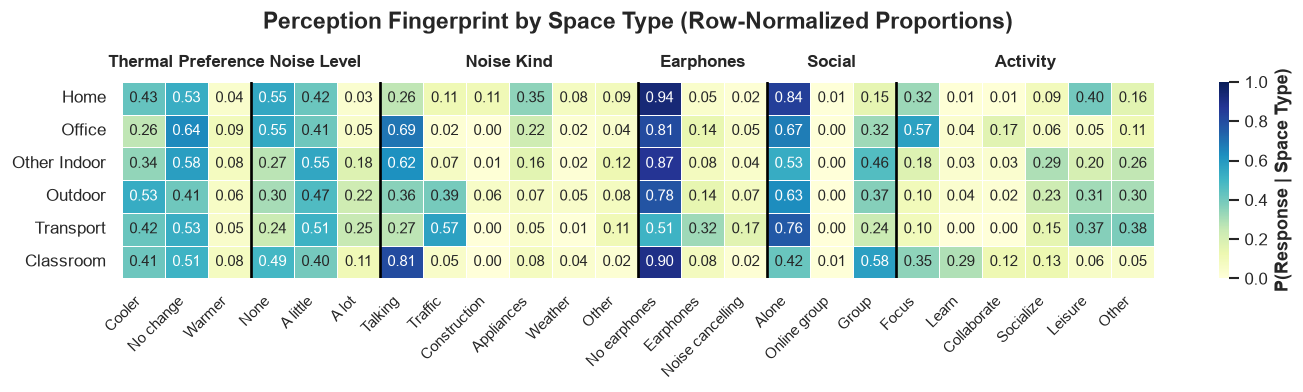

In [13]:
# A.1  Perception fingerprint — P(response | space type), row = space type
def cond_matrix(varlist):
    blocks = []
    for v in varlist:
        ct = pd.crosstab(df[SPACE], df[v], normalize='index')  # P(resp|space)
        ct = ct.reindex(space_order).reindex(columns=resp_order[v])
        ct.columns = pd.MultiIndex.from_product([[perc_label[v]], ct.columns])
        blocks.append(ct)
    M = pd.concat(blocks, axis=1)
    M.index = [space_label[s] for s in M.index]
    return M

M = cond_matrix(perception_vars)

fig, ax = plt.subplots(figsize=(12, 3.4))
sns.heatmap(M, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1,
            cbar_kws={'label':'P(Response | Space Type)'}, linewidths=.5,
            annot_kws={'size':9}, ax=ax)
ax.set_title('Perception Fingerprint by Space Type (Row-Normalized Proportions)',
             fontweight='bold', fontsize=14, pad=32)
cols = M.columns
prev = None
for i, (grp, _) in enumerate(cols):
    if grp != prev and i > 0:
        ax.axvline(i, color='black', lw=1.6)
    prev = grp
ax.set_xticklabels([c[1] for c in cols], rotation=45, ha='right', fontsize=9)
ax.set_xlabel(''); ax.set_ylabel('')
for grp in dict.fromkeys([c[0] for c in cols]):
    idxs = [i for i, c in enumerate(cols) if c[0] == grp]
    ax.text(np.mean(idxs)+0.5, -0.35, grp, ha='center', va='bottom',
            fontweight='bold', fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / 'perception_fingerprint_by_space_type.pdf', bbox_inches='tight')
plt.show()


### Figure 14 · Perception distinctiveness (lift)
*Paper §3.4 · ref 02·A2*

Dividing by each response's overall proportion turns a profile into a **signature**. *A lot* of noise is over-represented by ~**2.6×** in transportation and ~**2.4×** outdoors; *Group* is over-represented most in **classrooms** (lift ~2.1); and *Warmer* — rare overall — concentrates in the **office** (lift ~1.6), where air-conditioning can overshoot. Lift also makes the **source of noise** a spatial fingerprint: **traffic** accounts for most reported noise in transportation and a large share outdoors, while **talking** dominates the noise reported in classrooms and offices.

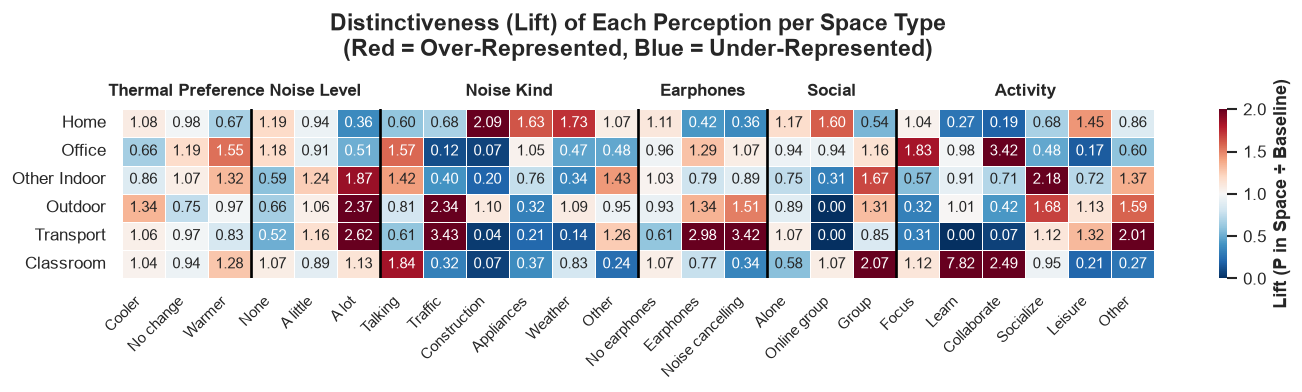

In [14]:
# A.2  Lift = P(response | space) / P(response overall).  >1 over-represented, <1 under.
def lift_matrix(varlist):
    blocks = []
    for v in varlist:
        cond = pd.crosstab(df[SPACE], df[v], normalize='index').reindex(space_order)
        base = df[v].value_counts(normalize=True)
        lift = cond.divide(base, axis=1).reindex(columns=resp_order[v])
        lift.columns = pd.MultiIndex.from_product([[perc_label[v]], lift.columns])
        blocks.append(lift)
    L = pd.concat(blocks, axis=1)
    L.index = [space_label[s] for s in L.index]
    return L

L = lift_matrix(perception_vars)

fig, ax = plt.subplots(figsize=(12, 3.4))
sns.heatmap(L, annot=True, fmt='.2f', cmap='RdBu_r', center=1, vmin=0, vmax=2,
            cbar_kws={'label':'Lift (P in Space ÷ Baseline)'}, linewidths=.5,
            annot_kws={'size':9}, ax=ax)
ax.set_title('Distinctiveness (Lift) of Each Perception per Space Type\n(Red = Over-Represented, Blue = Under-Represented)',
             fontweight='bold', fontsize=14, pad=32)
cols = L.columns
prev = None
for i, (grp, _) in enumerate(cols):
    if grp != prev and i > 0:
        ax.axvline(i, color='black', lw=1.6)
    prev = grp
ax.set_xticklabels([c[1] for c in cols], rotation=45, ha='right', fontsize=9)
ax.set_xlabel(''); ax.set_ylabel('')
for grp in dict.fromkeys([c[0] for c in cols]):
    idxs = [i for i, c in enumerate(cols) if c[0] == grp]
    ax.text(np.mean(idxs)+0.5, -0.35, grp, ha='center', va='bottom',
            fontweight='bold', fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / 'perception_lift_by_space_type.pdf', bbox_inches='tight')
plt.show()


### Figure 15 · Adjusted standardized residuals
*Paper §3.4 · ref 02·B2*

The third layer adds the statistical dimension, comparing each cell against independence. It agrees with the overall effect sizes: the association with space type is **strongest for what a person is doing and hearing** — Cramér's V ≈ **0.38** for group activity, **0.35** for solitary activity, **0.28** for noise kind — and **weakest for thermal preference (≈0.12)**. The residuals make the behavioral picture explicit: transportation and outdoor spaces for loud, traffic-driven noise; classrooms and offices for talking and group or focused activity; home for quiet, solitary responses; thermal preference only muted. With responses clustered within 106 participants, the **agreement of all three layers on the same ordering is the stronger evidence**. The central result: space type is written far more clearly into **what people do and hear** than into **how warm they feel**.

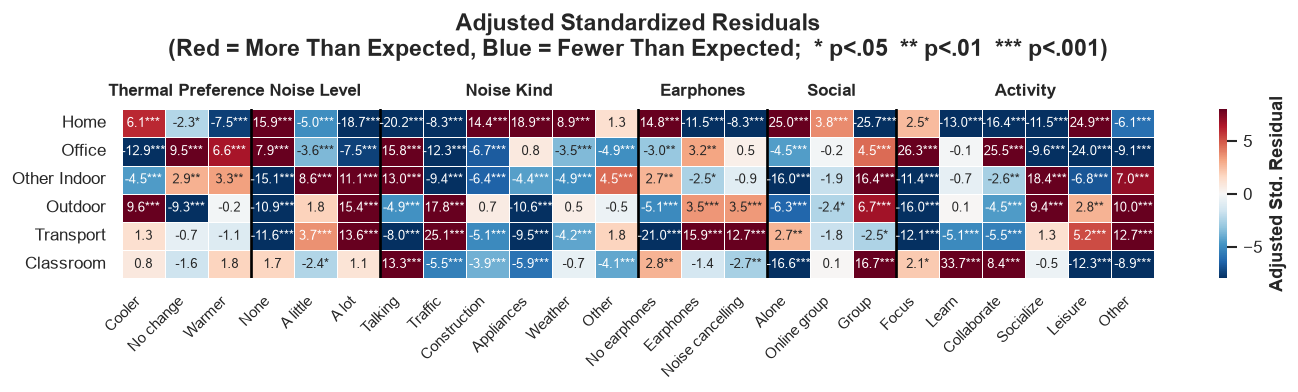

In [15]:
# B.2  Adjusted standardized residuals (which space x response cells stand out)
def adj_residuals(ct):
    n = ct.values.sum()
    row = ct.sum(axis=1).values[:, None]
    col = ct.sum(axis=0).values[None, :]
    exp = row @ col / n
    resid = (ct.values - exp) / np.sqrt(exp * (1 - row/n) * (1 - col/n))
    return pd.DataFrame(resid, index=ct.index, columns=ct.columns)

blocks = []
for v in perception_vars:
    ct = pd.crosstab(df[SPACE], df[v]).reindex(space_order).reindex(columns=resp_order[v])
    R = adj_residuals(ct)
    R.columns = pd.MultiIndex.from_product([[perc_label[v]], R.columns])
    blocks.append(R)
RES = pd.concat(blocks, axis=1)
RES.index = [space_label[s] for s in RES.index]

def stars(z):
    a = abs(z)
    return '***' if a > 3.29 else '**' if a > 2.58 else '*' if a > 1.96 else ''
annot = RES.map(lambda z: f"{z:.1f}{stars(z)}")

fig, ax = plt.subplots(figsize=(12, 3.4))
sns.heatmap(RES, annot=annot, fmt='', cmap='RdBu_r', center=0, vmin=-8, vmax=8,
            cbar_kws={'label':'Adjusted Std. Residual'}, linewidths=.5,
            annot_kws={'size':8}, ax=ax)
ax.set_title('Adjusted Standardized Residuals\n(Red = More Than Expected, Blue = Fewer Than Expected;  * p<.05  ** p<.01  *** p<.001)',
             fontweight='bold', fontsize=14, pad=32)
cols = RES.columns
prev = None
for i, (grp, _) in enumerate(cols):
    if grp != prev and i > 0:
        ax.axvline(i, color='black', lw=1.6)
    prev = grp
ax.set_xticklabels([c[1] for c in cols], rotation=45, ha='right', fontsize=9)
ax.set_xlabel(''); ax.set_ylabel('')
for grp in dict.fromkeys([c[0] for c in cols]):
    idxs = [i for i, c in enumerate(cols) if c[0] == grp]
    ax.text(np.mean(idxs)+0.5, -0.35, grp, ha='center', va='bottom',
            fontweight='bold', fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / 'perception_space_adjusted_residuals.pdf', bbox_inches='tight')
plt.show()


---
## 7 · Discussion and conclusions
*Paper §4 (Discussion) and Limitations*

The three analytical layers converge on a coherent characterization: **the clearest
separations between urban space types are behavioral and acoustic, not thermal** — what
people are doing and hearing identifies a space far more sharply than how warm they feel.
That a wrist-based micro-survey recovers a structure already documented by dosimetry,
interviews, and remote sensing lends confidence to the less obvious findings.

**Noise — a design target.** Commute spaces carry the loudest and most traffic-driven noise
(~a quarter of transportation responses report *a lot* of noise, against ~3% at home), so
traffic calming, acoustic buffering along transit corridors, and quieter routing would help
where distraction is worst. Indoors, **talking** rather than traffic dominates the noise in
classrooms and offices, pointing to acoustic treatment and layout that manage speech and
reverberation.

**Thermal — an energy message.** In this tropical, heavily air-conditioned setting,
**offices show the lowest cooling demand** of any space (~a quarter want *cooler*, with
occasional *warmer* requests where cooling overshoots), suggesting that **relaxing indoor
setpoints could save cooling energy at little comfort cost**. **Outdoor spaces show the
highest cooling demand**, pointing to shading, greenery, and passive cooling of public space
as the priority for thermal relief. Thermal preference is the weakest spatial marker and
reflects the immediate **controlled** setting more than the outdoor weather.

**Limitations.** The findings come from **106 participants in a young, homogeneous cohort**
(~73% aged 18–30, most recruited as students at a single university), sampled by convenience
rather than a representative frame — so the patterns describe this cohort in Singapore and
are **not population-level estimates**. Linked weather is **outdoor ambient**, a proxy for
the participant's actual (often indoor) microclimate. And because responses are clustered
within participants, significance markers are read as **descriptive screens**, with effect
sizes and cross-layer coherence as the primary evidence.

---
## 8 · Figure outputs and reproducibility

Running this notebook writes each figure below to `../figures/data_characterization/` under
its **manuscript filename**, so recompiling the manuscript reproduces the finished document:

```bash
# from the repository root
python -m pip install -r requirements.txt
jupyter nbconvert --to notebook --execute --inplace notebooks/cozie_singapore_companion.ipynb
latexmk -pdf cozie_sg.tex
```

| Manuscript figure | Notebook section | Output file (`figures/data_characterization/`) | Source tag |
|---|---|---|---|
| Figure 4  | Part 3 | `participant_engagement.pdf` | 01·E2 |
| Figure 5  | Part 3 | `weekly_temporal_cadence.pdf` | 01·D2 |
| Figure 6  | Part 3 | `space_type_timing_heatmaps.pdf` | 01·D4 |
| Figure 7  | Part 4 | `survey_battery_and_coverage.pdf` | 01·A1 |
| Figure 8  | Part 4 | `survey_response_flow.pdf` *(analytical source; manuscript uses the hand-organized `cozie-sankey-organized.png`)* | 01·C1 |
| Figure 9  | Part 4 | `wearable_health_windows.pdf` | 01·A2 |
| Figure 10 | Part 4 | `outdoor_weather_windows.pdf` | 01·A3 |
| Figure 11 | Part 5 | `cooling_preference.pdf` | 01·F2 |
| Figure 12 | Part 5 | `noise_characterization.pdf` | 01·G1 |
| Figure 13 | Part 6 | `perception_fingerprint_by_space_type.pdf` | 02·A1 |
| Figure 14 | Part 6 | `perception_lift_by_space_type.pdf` | 02·A2 |
| Figure 15 | Part 6 | `perception_space_adjusted_residuals.pdf` | 02·B2 |

**Not reproduced from public data:** Figures 1–2 are hand-drawn schematics; Figure 3
(`response_density_and_grid_counts.png`) requires exact home coordinates that are not part
of the public release. These remain committed assets.

*Figure code in this notebook is copied verbatim from the underlying analysis; only the data
path and the figure-output target were adjusted for this public repository.*